In [63]:
from sklearn.cluster import DBSCAN
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline

In [64]:
df_pca = pd.read_csv('../data/processed/df_pca.csv')

In [65]:
db_pipeline = Pipeline([
    ('dbscan', DBSCAN())
])

In [66]:
results_db = []
for n_comp in range(2, 6):
    X = df_pca.iloc[:, :n_comp].values
    for eps in np.arange(0.2, 1.1, 0.1).round(1):
        for ms in [5, 10, 20, 50]:

            labels = db_pipeline.set_params(dbscan__eps=eps, dbscan__min_samples=ms).fit_predict(X)

            mask = labels != -1
            n_clusters = len(set(labels[mask]))
            silhouette = silhouette_score(X[mask], labels[mask]) if n_clusters >= 2 else np.nan
            results_db.append({
                "n_comp": n_comp,
                "eps": eps,
                "min_samples": ms,
                "n_clusters": n_clusters,
                "noise_pct_100": (~mask).mean() * 100,
                "silhouette": silhouette,
            })

df_grid_db = pd.DataFrame(results_db)

In [67]:
df_grid_db.dropna().sort_values("silhouette", ascending=False).head(10).round(2)

,n_comp,eps,min_samples,n_clusters,noise_pct_100,silhouette
111,5,0.2,50,2,98.22,0.78
39,3,0.2,50,3,72.29,0.75
119,5,0.4,50,2,75.62,0.69
79,4,0.3,50,3,77.23,0.63
43,3,0.3,50,4,44.45,0.63
75,4,0.2,50,4,93.31,0.56
83,4,0.4,50,4,62.36,0.53
123,5,0.5,50,5,59.85,0.52
78,4,0.3,20,7,62.05,0.51
114,5,0.3,20,7,73.71,0.51


In [68]:
df_clean = pd.read_csv('../data/processed/df_clustered.csv')

BEST_NCOMP = 2
BEST_EPS = 0.4
BEST_MS = 50


X_db = df_pca.iloc[:, :BEST_NCOMP].values
db = db_pipeline.set_params(dbscan__eps=BEST_EPS, dbscan__min_samples=BEST_MS)
df_clean["cluster_dbscan"] = db.fit_predict(X_db)
df_clean["est_atypique_dbscan"] = df_clean["cluster_dbscan"] == -1

df_clean["cluster_dbscan"].value_counts(normalize=True).round(3)

cluster_dbscan
 0    0.750
 1    0.219
-1    0.032
Name: proportion, dtype: float64

In [69]:

def evaluate(X, labels):
    mask = labels != -1
    return {
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask]),
        "noise_pct": (~mask).mean() * 100,
    }

X_km = df_pca.iloc[:, :2].values
comparison = pd.DataFrame({
    "K-means": evaluate(X_km, df_clean["cluster_kmeans"].values),
    "DBSCAN": evaluate(X_db, df_clean["cluster_dbscan"].values),
}).T.round(3)
comparison

,silhouette,davies_bouldin,calinski_harabasz,noise_pct
K-means,0.449,0.774,9198.595,0.000
DBSCAN,0.459,0.734,6494.574,3.162


In [70]:
df_clean["cluster_final"] = df_clean["cluster_kmeans"]
df_clean.to_csv('../data/processed/df_clustered.csv', index=False)


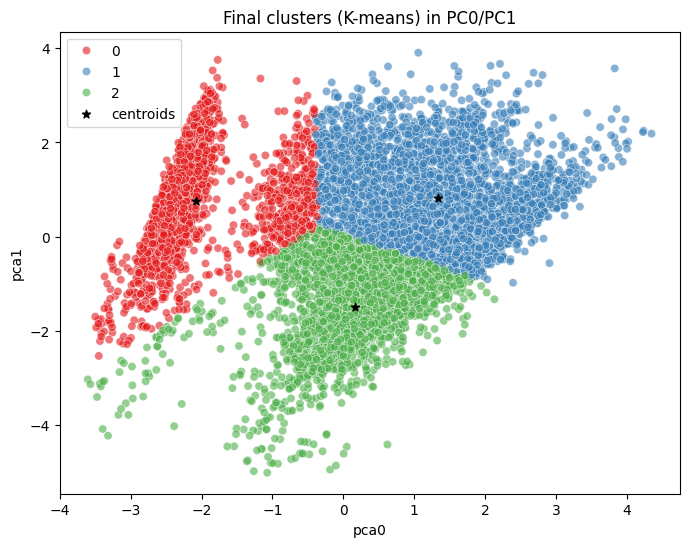

In [71]:
centroids = df_pca[["pca0", "pca1"]].groupby(df_clean["cluster_final"]).mean()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca["pca0"], y=df_pca["pca1"], hue=df_clean["cluster_final"], palette="Set1", alpha=0.6)
plt.scatter(centroids["pca0"], centroids["pca1"], c="black", marker="*", label="centroids")
plt.legend()
plt.title("Final clusters (K-means) in PC0/PC1")
plt.show()

In [72]:
cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

In [73]:
df_log = np.log1p(df_clean[cols])

In [74]:
scaler_pipeline = Pipeline([
    ('scaler', StandardScaler().set_output(transform='pandas'))
])

In [75]:
df_scaled = scaler_pipeline.fit_transform(df_log)

In [76]:
means_std = df_scaled.groupby(df_clean["cluster_final"]).mean().round(2)
means_std

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster_final,,,,,,,
0,0.50,-1.40,-0.80,-1.02,1.00,-0.12,-0.01
1,0.45,0.78,0.87,0.48,-0.03,0.60,0.57
2,-0.88,0.24,-0.33,0.28,-0.75,-0.56,-0.61


In [77]:
means_real = df_clean.groupby("cluster_final")[cols].mean().round(0)
means_real

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster_final,,,,,,,
0,2177.0,24.0,19.0,5.0,2009.0,3983.0,1631.0
1,2264.0,2199.0,1411.0,788.0,1096.0,6526.0,2889.0
2,331.0,467.0,149.0,318.0,53.0,2688.0,560.0


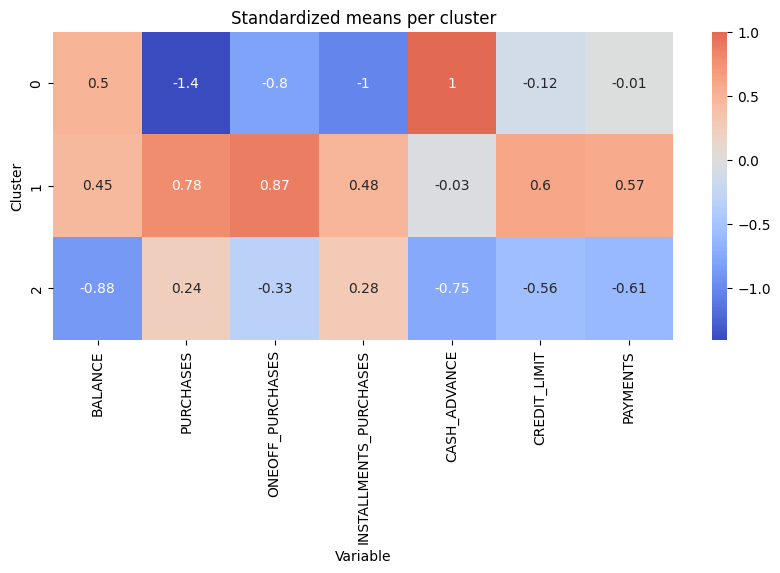

In [78]:
plt.figure(figsize=(10, 4))
sns.heatmap(means_std, annot=True, cmap="coolwarm", center=0)
plt.title("Standardized means per cluster")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.show()

In [79]:
means_real.round(0).sort_values('CREDIT_LIMIT', ascending=False)

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster_final,,,,,,,
1,2264.0,2199.0,1411.0,788.0,1096.0,6526.0,2889.0
0,2177.0,24.0,19.0,5.0,2009.0,3983.0,1631.0
2,331.0,467.0,149.0,318.0,53.0,2688.0,560.0


In [80]:
cluster_names = {
    0: "Cash Users",
    1: "Premium Clients",
    2: "Low Activity Clients",
}

In [81]:
df_clean["target"] = df_clean["cluster_final"].map(cluster_names)

In [82]:
print(set(df_clean["cluster_final"].unique()) - set(cluster_names.keys()))

set()


In [83]:
# check for missing values in target column 

print(df_clean["target"].isna().sum())

0


In [84]:
print(df_clean["cluster_final"].value_counts(normalize=True).round(3))
print(df_clean["target"].value_counts(normalize=True).round(3))

cluster_final
1    0.379
2    0.350
0    0.271
Name: proportion, dtype: float64
target
Premium Clients         0.379
Low Activity Clients    0.350
Cash Users              0.271
Name: proportion, dtype: float64


In [85]:
df_clean.to_csv('../data/processed/df_clustered.csv', index=False)

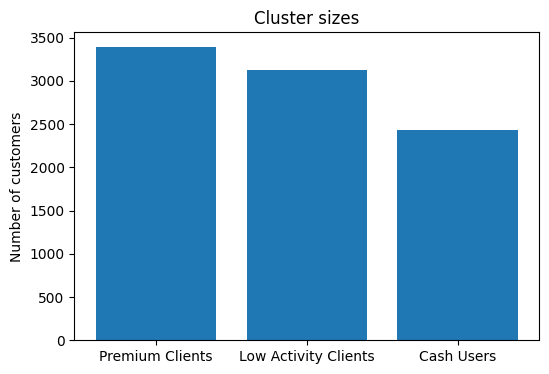

In [86]:
sizes = df_clean["target"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(sizes.index, sizes.values)
plt.title("Cluster sizes")
plt.ylabel("Number of customers")
plt.show()

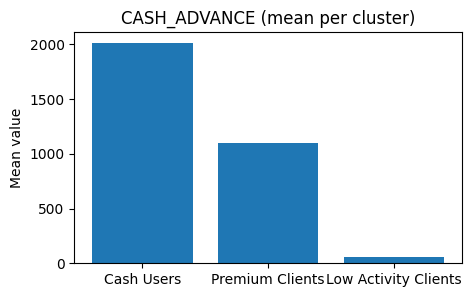

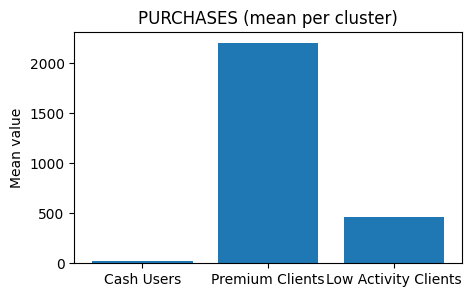

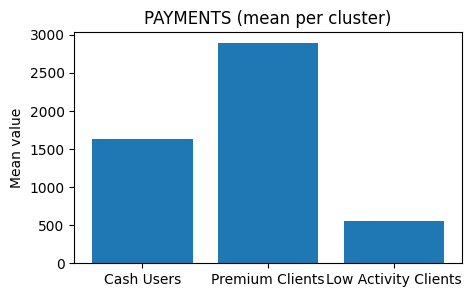

In [87]:
for col in ["CASH_ADVANCE", "PURCHASES", "PAYMENTS"]:
    plt.figure(figsize=(5, 3))
    plt.bar(means_real.index.map(cluster_names), means_real[col])
    plt.title(f"{col} (mean per cluster)")
    plt.ylabel("Mean value")
    plt.show()